# Comparative Analysis: Three Argumentative Microtext Corpora

Comparing the original corpus (Peldszus & Stede, 2016), the crowdsourced extension (Skeppstedt et al., 2018), and our LLM-generated corpus (Qwen).

Metrics based on Section 5 of Peldszus & Stede (2016), plus lexical diversity measures.

In [72]:
# install if needed
# !pip install matplotlib numpy

import json
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## load the data

In [73]:
with open('/home/raheleh/Projects/Personal/IM-final/arg-microtexts/original_data.json') as f:
    orig = json.load(f)
with open('/home/raheleh/Projects/Personal/IM-final/arg-microtexts/original_data_2.json') as f:
    crowd = json.load(f)
with open('/home/raheleh/Projects/Personal/IM-final/results/qwen_microtext_corpus.json') as f:
    qwen = json.load(f)

# make sure they loaded correctly
for name, data in [('orig', orig), ('crowd', crowd), ('qwen', qwen)]:
    assert isinstance(data, list), f"{name} is not a list!"
    assert isinstance(data[0], dict), f"{name}[0] is not a dict!"
    assert 'arggraph' in data[0], f"{name}[0] has no 'arggraph' key!"

names = ['Original (2016)', 'Crowdsource (2018)', 'LLM (Qwen)']
corpora = [orig, crowd, qwen]
colors = ['#2196F3', '#FF9800', '#4CAF50']

print(f"original:    {len(orig)} texts, first item keys: {list(orig[0].keys())}")
print(f"crowdsource: {len(crowd)} texts, first item keys: {list(crowd[0].keys())}")
print(f"qwen:        {len(qwen)} texts, first item keys: {list(qwen[0].keys())}")

original:    112 texts, first item keys: ['arggraph', '@text']
crowdsource: 171 texts, first item keys: ['arggraph', '@text']
qwen:        138 texts, first item keys: ['arggraph', '@text']


## helper functions

In [74]:
def get_edges(item):
    """split edges into rel and seg"""
    rel = [(e['@src'], e['@trg'], e['@type']) for e in item['arggraph']['edge'] if e['@type'] != 'seg']
    seg = [(e['@src'], e['@trg']) for e in item['arggraph']['edge'] if e['@type'] == 'seg']
    return rel, seg

def get_root(item):
    """find the root ADU (not a source in any relation edge)"""
    adus = [a['@id'] for a in item['arggraph']['adu']]
    rel, _ = get_edges(item)
    sources = set(e[0] for e in rel)
    roots = [a for a in adus if a not in sources]
    return roots[0] if roots else adus[0]

def adu_position(adu_id):
    """extract the number from 'a3' -> 3"""
    return int(adu_id[1:])

## 1. text length (Peldszus & Stede 2016, Table 1)

In [75]:
print("text length in ADUs")
print("-" * 65)
print(f"{'ADUs':<6} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)

for c in range(2, 11):
    vals = []
    for corp in corpora:
        n = sum(1 for x in corp if len(x['arggraph']['adu']) == c)
        vals.append(n)
    if sum(vals) > 0:
        line = f"  {c:<4}"
        for v, corp in zip(vals, corpora):
            pct = v / len(corp) * 100
            line += f" {v:>5} ({pct:>5.1f}%)"
        print(line)

print()
for name, corp in zip(names, corpora):
    lengths = [len(x['arggraph']['adu']) for x in corp]
    print(f"{name}: mean={np.mean(lengths):.1f}, median={np.median(lengths):.0f}, std={np.std(lengths):.1f}")

text length in ADUs
-----------------------------------------------------------------
ADUs         Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  2        0 (  0.0%)     2 (  1.2%)     0 (  0.0%)
  3        3 (  2.7%)    12 (  7.0%)     0 (  0.0%)
  4       11 (  9.8%)    33 ( 19.3%)     0 (  0.0%)
  5       71 ( 63.4%)    46 ( 26.9%)    19 ( 13.8%)
  6       24 ( 21.4%)    40 ( 23.4%)    42 ( 30.4%)
  7        2 (  1.8%)    23 ( 13.5%)    46 ( 33.3%)
  8        0 (  0.0%)     7 (  4.1%)    24 ( 17.4%)
  9        0 (  0.0%)     7 (  4.1%)     6 (  4.3%)
  10       1 (  0.9%)     1 (  0.6%)     1 (  0.7%)

Original (2016): mean=5.1, median=5, std=0.8
Crowdsource (2018): mean=5.5, median=5, std=1.5
LLM (Qwen): mean=6.7, median=7, std=1.1


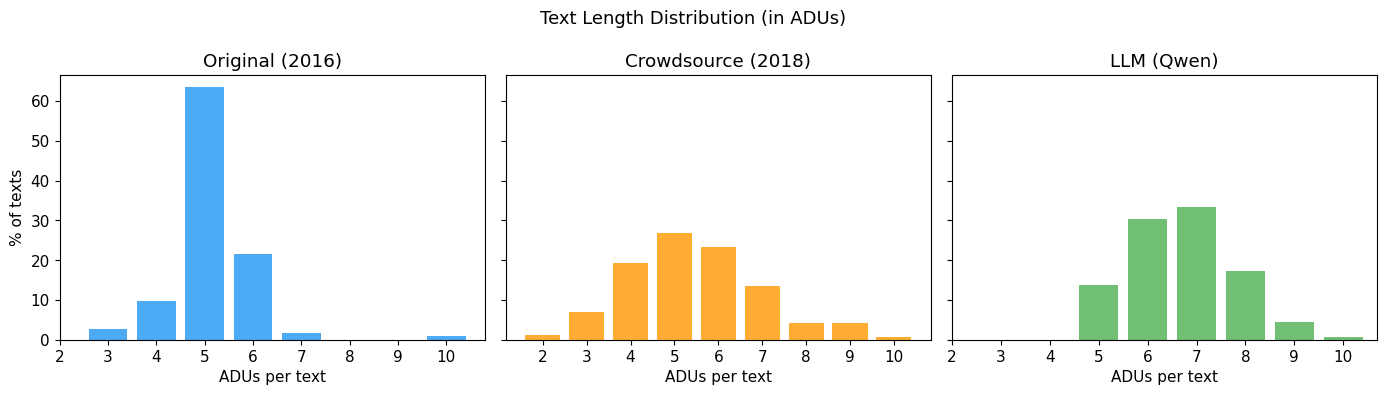

In [76]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, corp, name, color in zip(axes, corpora, names, colors):
    lengths = [len(x['arggraph']['adu']) for x in corp]
    counts = Counter(lengths)
    xs = sorted(counts.keys())
    ys = [counts[x] / len(corp) * 100 for x in xs]
    ax.bar(xs, ys, color=color, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('ADUs per text')
    ax.set_xticks(range(2, 11))

axes[0].set_ylabel('% of texts')
plt.suptitle('Text Length Distribution (in ADUs)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. central claim position ( Peldszus & stede 2016, Table 2)

they divide each text into 5 equal parts and check where the central claim falls.

In [77]:
def claim_position_fifth(item):
    """which fifth of the text is the central claim in?"""
    root = get_root(item)
    root_pos = adu_position(root)  # 1-indexed
    n_adus = len(item['arggraph']['adu'])
    # which fifth? (1/5, 2/5, 3/5, 4/5, 5/5)
    fifth = int(np.ceil(root_pos / n_adus * 5))
    return min(fifth, 5)

print("central claim position")
print("-" * 65)
print(f"{'Position':<10} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)

for pos in range(1, 6):
    vals = []
    for corp in corpora:
        n = sum(1 for x in corp if claim_position_fifth(x) == pos)
        vals.append(n)
    label = f"  {pos}/5"
    line = f"{label:<10}"
    for v, corp in zip(vals, corpora):
        pct = v / len(corp) * 100
        line += f" {v:>5} ({pct:>5.1f}%)"
    print(line)

central claim position
-----------------------------------------------------------------
Position         Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  1/5         48 ( 42.9%)   104 ( 60.8%)   137 ( 99.3%)
  2/5         18 ( 16.1%)    44 ( 25.7%)     1 (  0.7%)
  3/5         16 ( 14.3%)     6 (  3.5%)     0 (  0.0%)
  4/5          3 (  2.7%)     3 (  1.8%)     0 (  0.0%)
  5/5         27 ( 24.1%)    14 (  8.2%)     0 (  0.0%)


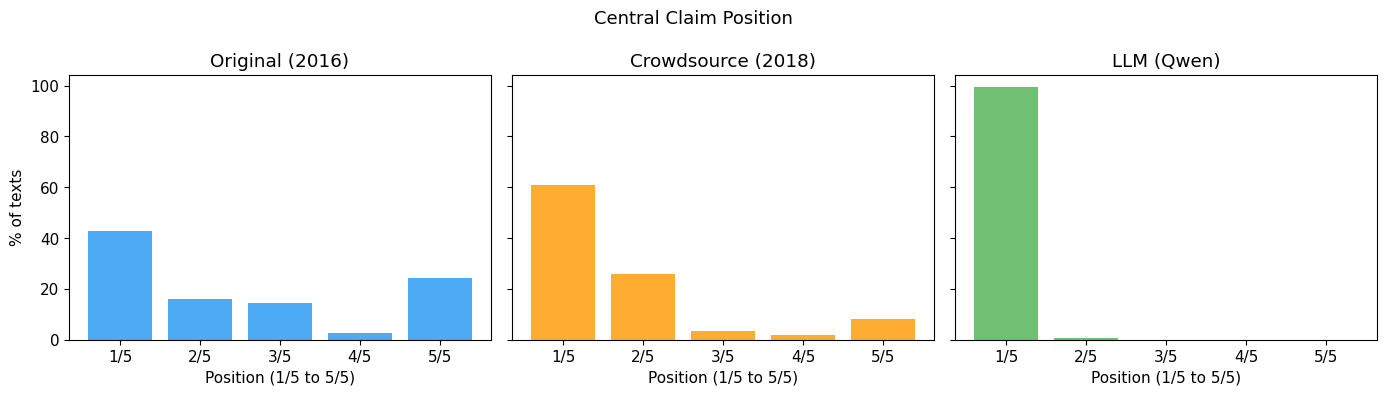

In [78]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, corp, name, color in zip(axes, corpora, names, colors):
    fifths = [claim_position_fifth(x) for x in corp]
    counts = Counter(fifths)
    xs = range(1, 6)
    ys = [counts.get(x, 0) / len(corp) * 100 for x in xs]
    ax.bar(xs, ys, color=color, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Position (1/5 to 5/5)')
    ax.set_xticks(xs)
    ax.set_xticklabels(['1/5', '2/5', '3/5', '4/5', '5/5'])

axes[0].set_ylabel('% of texts')
plt.suptitle('Central Claim Position', fontsize=13)
plt.tight_layout()
plt.savefig('fig_claim_position.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. argumentative role (Peldszus & Stede 2016n , Section 5.3)

proponent vs opponent segments, and how many opponent segments per text.

In [79]:
# overall pro/opp counts
print("argumentative role distribution")
print("-" * 65)
print(f"{'Role':<10} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)

for role in ['pro', 'opp']:
    line = f"  {role:<8}"
    for corp in corpora:
        n = sum(1 for x in corp for a in x['arggraph']['adu'] if a['@type'] == role)
        total = sum(len(x['arggraph']['adu']) for x in corp)
        pct = n / total * 100
        line += f" {n:>5} ({pct:>5.1f}%)"
    print(line)

# opponent segments per text
print()
print("number of opponent segments per text")
print("-" * 65)
print(f"{'# opp':<10} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)

for n_opp in range(0, 5):
    line = f"  {n_opp:<8}"
    for corp in corpora:
        n = sum(1 for x in corp 
                if sum(1 for a in x['arggraph']['adu'] if a['@type'] == 'opp') == n_opp)
        pct = n / len(corp) * 100
        line += f" {n:>5} ({pct:>5.1f}%)"
    print(line)

argumentative role distribution
-----------------------------------------------------------------
Role             Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  pro        451 ( 78.3%)   805 ( 86.4%)   750 ( 81.1%)
  opp        125 ( 21.7%)   127 ( 13.6%)   175 ( 18.9%)

number of opponent segments per text
-----------------------------------------------------------------
# opp            Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  0           15 ( 13.4%)    67 ( 39.2%)     0 (  0.0%)
  1           74 ( 66.1%)    83 ( 48.5%)   101 ( 73.2%)
  2           18 ( 16.1%)    19 ( 11.1%)    37 ( 26.8%)
  3            5 (  4.5%)     2 (  1.2%)     0 (  0.0%)
  4            0 (  0.0%)     0 (  0.0%)     0 (  0.0%)


## 4. position of opponent segments (Peldszus & Stede 2016 ,Table 3)

In [80]:
print("position of opponent segments")
print("-" * 65)
print(f"{'Position':<10} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)

for pos in range(1, 6):
    line = f"  {pos}/5     "
    for corp in corpora:
        count = 0
        for x in corp:
            n_adus = len(x['arggraph']['adu'])
            for a in x['arggraph']['adu']:
                if a['@type'] == 'opp':
                    a_pos = adu_position(a['@id'])
                    fifth = min(int(np.ceil(a_pos / n_adus * 5)), 5)
                    if fifth == pos:
                        count += 1
        line += f" {count:>14}"
    print(line)

position of opponent segments
-----------------------------------------------------------------
Position         Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  1/5                  18              3              0
  2/5                  30             28             15
  3/5                  23             27            106
  4/5                  36             36             42
  5/5                  18             33             12


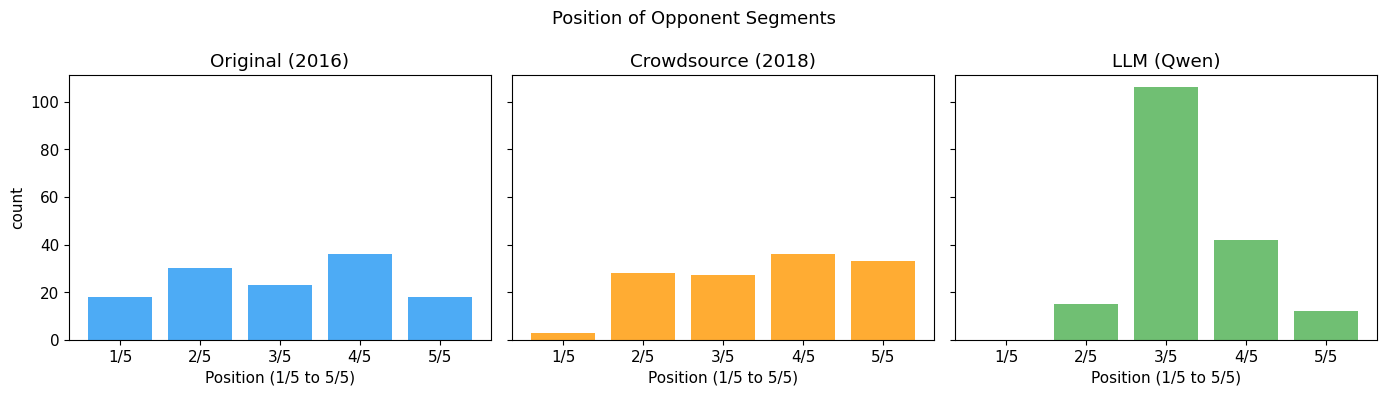

In [81]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, corp, name, color in zip(axes, corpora, names, colors):
    opp_positions = []
    for x in corp:
        n_adus = len(x['arggraph']['adu'])
        for a in x['arggraph']['adu']:
            if a['@type'] == 'opp':
                a_pos = adu_position(a['@id'])
                fifth = min(int(np.ceil(a_pos / n_adus * 5)), 5)
                opp_positions.append(fifth)
    
    counts = Counter(opp_positions)
    xs = range(1, 6)
    ys = [counts.get(x, 0) for x in xs]
    ax.bar(xs, ys, color=color, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Position (1/5 to 5/5)')
    ax.set_xticks(xs)
    ax.set_xticklabels(['1/5', '2/5', '3/5', '4/5', '5/5'])

axes[0].set_ylabel('count')
plt.suptitle('Position of Opponent Segments', fontsize=13)
plt.tight_layout()
plt.savefig('fig_opponent_position.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. attachment distance (Peldszus & Stede 2016, Section 5.5, Figure 3)

distance between source and target of each relation. negative = backward (target before source), positive = forward.

In [82]:
def get_attachment_distances(corpus):
    distances = []
    for x in corpus:
        rel, _ = get_edges(x)
        for src, trg, rtype in rel:
            src_pos = adu_position(src)
            trg_pos = adu_position(trg)
            dist = trg_pos - src_pos  # negative = backward
            distances.append(dist)
    return distances

d_orig = get_attachment_distances(orig)
d_crowd = get_attachment_distances(crowd)
d_qwen = get_attachment_distances(qwen)

# table
print("attachment distance distribution")
print("-" * 65)
print(f"{'Dist':<6} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)

for d in range(-9, 6):
    v1 = d_orig.count(d)
    v2 = d_crowd.count(d)
    v3 = d_qwen.count(d)
    if v1 + v2 + v3 > 0:
        p1 = v1/len(d_orig)*100
        p2 = v2/len(d_crowd)*100
        p3 = v3/len(d_qwen)*100
        print(f"  {d:<4} {v1:>5} ({p1:>5.1f}%) {v2:>5} ({p2:>5.1f}%) {v3:>5} ({p3:>5.1f}%)")

print()
# adjacent vs non-adjacent
for name, dists in zip(names, [d_orig, d_crowd, d_qwen]):
    adj = sum(1 for d in dists if abs(d) == 1)
    print(f"{name}: adjacent={adj/len(dists)*100:.1f}%, non-adjacent={100-adj/len(dists)*100:.1f}%")

attachment distance distribution
-----------------------------------------------------------------
Dist         Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  -9       0 (  0.0%)     0 (  0.0%)     1 (  0.1%)
  -8       0 (  0.0%)     1 (  0.1%)     6 (  0.8%)
  -7       0 (  0.0%)     2 (  0.3%)    30 (  3.8%)
  -6       1 (  0.2%)    10 (  1.3%)    66 (  8.4%)
  -5       4 (  0.9%)    29 (  3.8%)    85 ( 10.8%)
  -4      21 (  4.5%)    52 (  6.8%)    88 ( 11.2%)
  -3      49 ( 10.6%)    98 ( 12.9%)    58 (  7.4%)
  -2      56 ( 12.1%)   201 ( 26.4%)   124 ( 15.8%)
  -1     209 ( 45.0%)   292 ( 38.4%)   328 ( 41.7%)
  0        0 (  0.0%)     1 (  0.1%)     0 (  0.0%)
  1       52 ( 11.2%)    34 (  4.5%)     1 (  0.1%)
  2       38 (  8.2%)    16 (  2.1%)     0 (  0.0%)
  3       10 (  2.2%)     9 (  1.2%)     0 (  0.0%)
  4       19 (  4.1%)     6 (  0.8%)     0 (  0.0%)
  5        5 (  1.1%)     8 (  1.1%)     0 (  0.0%)

Or

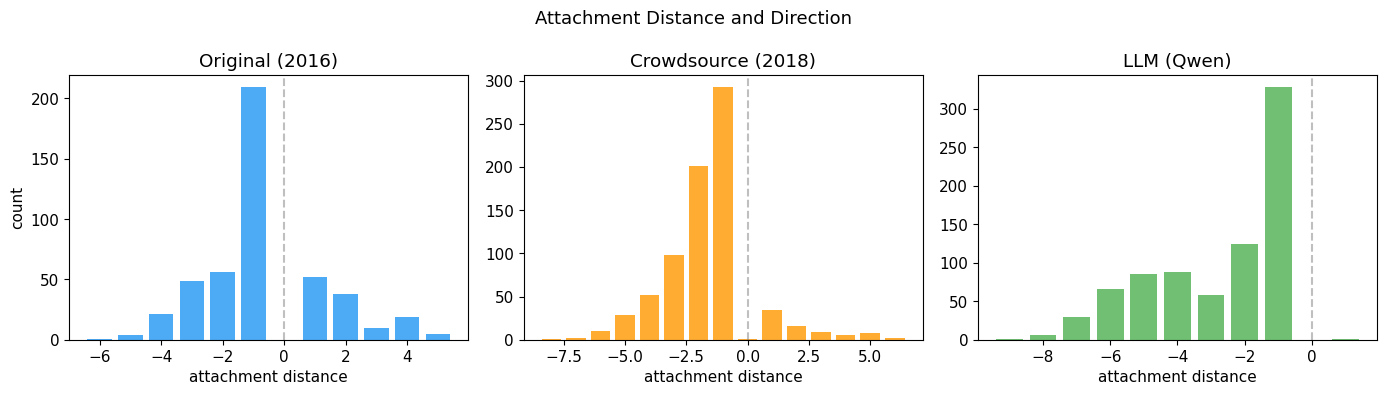

In [83]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, dists, name, color in zip(axes, [d_orig, d_crowd, d_qwen], names, colors):
    counts = Counter(dists)
    xs = sorted(counts.keys())
    ys = [counts[x] for x in xs]
    ax.bar(xs, ys, color=color, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('attachment distance')
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

axes[0].set_ylabel('count')
plt.suptitle('Attachment Distance and Direction', fontsize=13)
plt.tight_layout()
plt.savefig('fig_attachment_distance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. tree shape — depth and branching

In [84]:
def tree_stats(corpus):
    depths = []
    branching = []
    for x in corpus:
        adus = [a['@id'] for a in x['arggraph']['adu']]
        rel, _ = get_edges(x)
        parent = {s: t for s, t, _ in rel}
        
        # max depth
        max_d = 0
        for a in adus:
            d, cur, seen = 0, a, set()
            while cur in parent and cur not in seen:
                seen.add(cur)
                cur = parent[cur]
                d += 1
            max_d = max(max_d, d)
        depths.append(max_d)
        
        # direct to root
        root = get_root(x)
        br = sum(1 for s, t, _ in rel if t == root)
        branching.append(br)
    
    return depths, branching

dep_o, br_o = tree_stats(orig)
dep_c, br_c = tree_stats(crowd)
dep_q, br_q = tree_stats(qwen)

print("tree depth distribution")
print("-" * 65)
print(f"{'Depth':<8} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)
for d in range(0, 6):
    v1, v2, v3 = dep_o.count(d), dep_c.count(d), dep_q.count(d)
    if v1+v2+v3 > 0:
        print(f"  {d:<6} {v1:>5} ({v1/len(orig)*100:>5.1f}%) {v2:>5} ({v2/len(crowd)*100:>5.1f}%) {v3:>5} ({v3/len(qwen)*100:>5.1f}%)")

print()
print("direct-to-root branching")
print("-" * 65)
print(f"{'Branch':<8} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)
for b in range(1, 9):
    v1, v2, v3 = br_o.count(b), br_c.count(b), br_q.count(b)
    if v1+v2+v3 > 0:
        print(f"  {b:<6} {v1:>5} ({v1/len(orig)*100:>5.1f}%) {v2:>5} ({v2/len(crowd)*100:>5.1f}%) {v3:>5} ({v3/len(qwen)*100:>5.1f}%)")

print()
for name, dep, br in zip(names, [dep_o,dep_c,dep_q], [br_o,br_c,br_q]):
    print(f"{name}: mean depth={np.mean(dep):.2f}, mean branching={np.mean(br):.2f}")

tree depth distribution
-----------------------------------------------------------------
Depth          Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  1         44 ( 39.3%)    54 ( 31.6%)     0 (  0.0%)
  2         60 ( 53.6%)    89 ( 52.0%)   137 ( 99.3%)
  3          8 (  7.1%)    25 ( 14.6%)     1 (  0.7%)
  4          0 (  0.0%)     2 (  1.2%)     0 (  0.0%)
  5          0 (  0.0%)     1 (  0.6%)     0 (  0.0%)

direct-to-root branching
-----------------------------------------------------------------
Branch         Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  1         17 ( 15.2%)    43 ( 25.1%)     0 (  0.0%)
  2         35 ( 31.2%)    44 ( 25.7%)     0 (  0.0%)
  3         46 ( 41.1%)    57 ( 33.3%)    25 ( 18.1%)
  4         11 (  9.8%)    23 ( 13.5%)    59 ( 42.8%)
  5          3 (  2.7%)     4 (  2.3%)    39 ( 28.3%)
  6          0 (  0.0%)     0 (  0.0%)

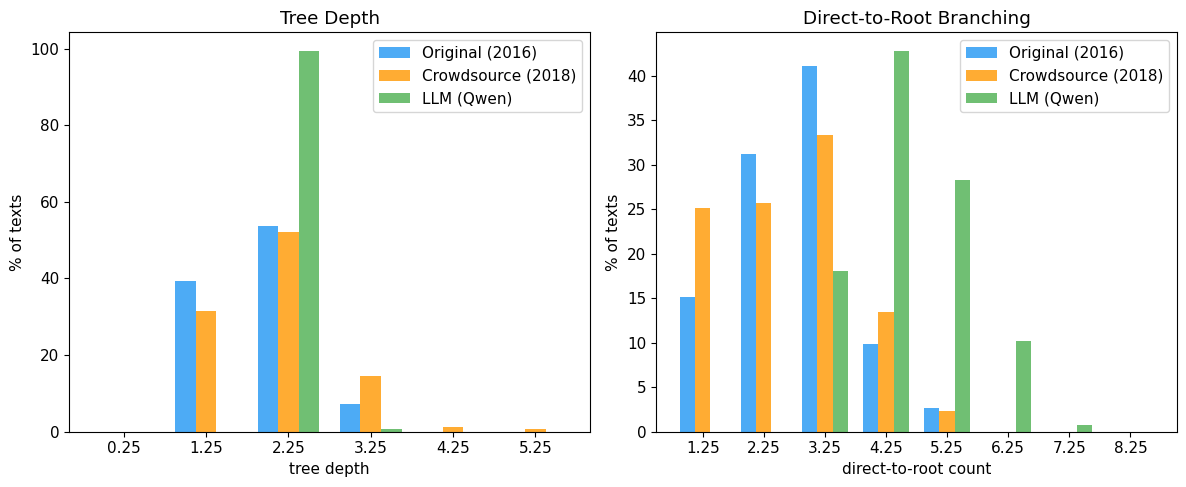

In [85]:
# plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# depth
x = np.arange(0, 6)
w = 0.25
for i, (dep, name, color) in enumerate(zip([dep_o, dep_c, dep_q], names, colors)):
    counts = [dep.count(d) / len(dep) * 100 for d in x]
    ax1.bar(x + i*w, counts, w, label=name, color=color, alpha=0.8)
ax1.set_xlabel('tree depth')
ax1.set_ylabel('% of texts')
ax1.set_title('Tree Depth')
ax1.set_xticks(x + w)
ax1.legend()

# branching
x = np.arange(1, 9)
for i, (br, name, color) in enumerate(zip([br_o, br_c, br_q], names, colors)):
    counts = [br.count(b) / len(br) * 100 for b in x]
    ax2.bar(x + i*w, counts, w, label=name, color=color, alpha=0.8)
ax2.set_xlabel('direct-to-root count')
ax2.set_ylabel('% of texts')
ax2.set_title('Direct-to-Root Branching')
ax2.set_xticks(x + w)
ax2.legend()

plt.tight_layout()
plt.savefig('fig_tree_shape.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Relation Type

relation type distribution (support vs attack)
-----------------------------------------------------------------
Type             Original    Crowdsource     LLM (Qwen)
-----------------------------------------------------------------
  support    293 ( 63.1%)   547 ( 71.9%)   437 ( 55.5%)
  attack     171 ( 36.9%)   214 ( 28.1%)   350 ( 44.5%)


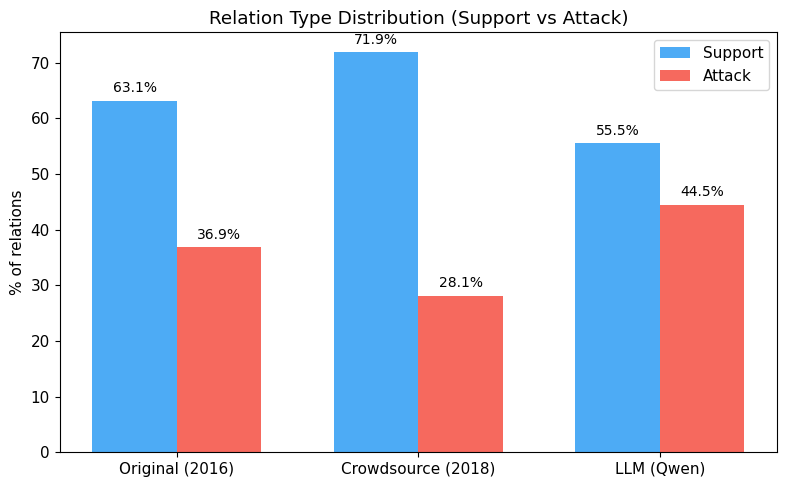

In [86]:
attack_types = {'reb', 'und'}

print("relation type distribution (support vs attack)")
print("-" * 65)
print(f"{'Type':<10} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 65)

support_counts, attack_counts = [], []
for corp in corpora:
    rels = [rtype for x in corp for _, _, rtype in get_edges(x)[0]]
    n_att = sum(1 for r in rels if r in attack_types)
    attack_counts.append((n_att, len(rels)))
    support_counts.append((len(rels) - n_att, len(rels)))

line = f"  {'support':<8}"
for n, total in support_counts:
    line += f" {n:>5} ({n/total*100:>5.1f}%)"
print(line)

line = f"  {'attack':<8}"
for n, total in attack_counts:
    line += f" {n:>5} ({n/total*100:>5.1f}%)"
print(line)

# plot
support_pct = [n/total*100 for n, total in support_counts]
attack_pct = [n/total*100 for n, total in attack_counts]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, support_pct, w, label='Support', color='#2196F3', alpha=0.8)
ax.bar(x + w/2, attack_pct, w, label='Attack', color='#F44336', alpha=0.8)

for i, (sp, ap) in enumerate(zip(support_pct, attack_pct)):
    ax.text(i - w/2, sp + 1, f'{sp:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.text(i + w/2, ap + 1, f'{ap:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('% of relations')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_title('Relation Type Distribution (Support vs Attack)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_relation_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. restatements (Skeppstedt et al. 2018, Section 4.2)

In [87]:
print("restatement rates")
print("-" * 50)
for name, corp in zip(names, corpora):
    rest = sum(1 for x in corp 
               if len(x['arggraph']['edu']) != len(x['arggraph']['adu']))
    print(f"  {name}: {rest}/{len(corp)} ({rest/len(corp)*100:.1f}%)")

restatement rates
--------------------------------------------------
  Original (2016): 0/112 (0.0%)
  Crowdsource (2018): 27/171 (15.8%)
  LLM (Qwen): 66/138 (47.8%)


## 9. lexical diversity

In [88]:
def tokenize(text):
    return re.findall(r'[a-z]+', text.lower())

def lex_stats(corpus, name):
    all_tok = []
    ttrs = []
    
    for x in corpus:
        toks = tokenize(x['@text'])
        all_tok.extend(toks)
        if toks:
            ttrs.append(len(set(toks)) / len(toks))
    
    # within-topic jaccard
    by_topic = {}
    for x in corpus:
        tid = x['arggraph'].get('@topic_id', 'unknown')
        by_topic.setdefault(tid, []).append(set(tokenize(x['@text'])))
    
    jaccards = []
    for tid, sets in by_topic.items():
        for i in range(len(sets)):
            for j in range(i+1, len(sets)):
                inter = len(sets[i] & sets[j])
                union = len(sets[i] | sets[j])
                if union:
                    jaccards.append(inter / union)
    
    return {
        'total_tok': len(all_tok),
        'vocab': len(set(all_tok)),
        'corpus_ttr': len(set(all_tok)) / len(all_tok),
        'mean_ttr': np.mean(ttrs),
        'mean_len': len(all_tok) / len(corpus),
        'mean_jacc': np.mean(jaccards) if jaccards else 0,
        'max_jacc': max(jaccards) if jaccards else 0,
    }

l_o = lex_stats(orig, "Original")
l_c = lex_stats(crowd, "Crowdsource")
l_q = lex_stats(qwen, "LLM")

print("lexical diversity")
print("-" * 75)
print(f"{'Metric':<35} {'Original':>12} {'Crowdsource':>12} {'LLM (Qwen)':>12}")
print("-" * 75)
for label, key, fmt in [
    ('Mean text length (tokens)', 'mean_len', '.1f'),
    ('Total tokens', 'total_tok', 'd'),
    ('Vocabulary size', 'vocab', 'd'),
    ('Corpus TTR', 'corpus_ttr', '.3f'),
    ('Mean per-text TTR', 'mean_ttr', '.3f'),
    ('Mean within-topic Jaccard', 'mean_jacc', '.3f'),
    ('Max within-topic Jaccard', 'max_jacc', '.3f'),
]:
    v1, v2, v3 = l_o[key], l_c[key], l_q[key]
    f = f"{{:>12{fmt}}}"
    print(f"{label:<35} {f.format(v1)} {f.format(v2)} {f.format(v3)}")

lexical diversity
---------------------------------------------------------------------------
Metric                                  Original  Crowdsource   LLM (Qwen)
---------------------------------------------------------------------------
Mean text length (tokens)                   71.2         74.1         97.8
Total tokens                                7978        12679        13491
Vocabulary size                             2028         2140         1938
Corpus TTR                                 0.254        0.169        0.144
Mean per-text TTR                          0.790        0.730        0.869
Mean within-topic Jaccard                  0.127        0.183        0.321
Max within-topic Jaccard                   0.320        0.323        0.713


## 10. opposition markers

In [89]:
markers = ['critics argue', 'opponents argue', 'some argue', 'proponents argue', 'while some']

print("opposition marker frequency")
print("-" * 75)
print(f"{'Marker':<25} {'Original':>14} {'Crowdsource':>14} {'LLM (Qwen)':>14}")
print("-" * 75)

for marker in markers:
    line = f"  {marker:<23}"
    for corp in corpora:
        n = sum(1 for x in corp if marker in x['@text'].lower())
        pct = n / len(corp) * 100
        line += f" {n:>5} ({pct:>4.0f}%)"
    print(line)

# any "X argue"
print()
for name, corp in zip(names, corpora):
    n = sum(1 for x in corp 
            if any(m in x['@text'].lower() for m in ['critics argue', 'opponents argue', 'some argue', 'proponents argue']))
    print(f"{name}: {n}/{len(corp)} ({n/len(corp)*100:.0f}%) have any 'X argue' marker")

opposition marker frequency
---------------------------------------------------------------------------
Marker                          Original    Crowdsource     LLM (Qwen)
---------------------------------------------------------------------------
  critics argue               0 (   0%)     0 (   0%)    74 (  54%)
  opponents argue             0 (   0%)     0 (   0%)    37 (  27%)
  some argue                  0 (   0%)     0 (   0%)    10 (   7%)
  proponents argue            0 (   0%)     0 (   0%)     4 (   3%)
  while some                  0 (   0%)     0 (   0%)    26 (  19%)

Original (2016): 0/112 (0%) have any 'X argue' marker
Crowdsource (2018): 0/171 (0%) have any 'X argue' marker
LLM (Qwen): 125/138 (91%) have any 'X argue' marker


## 11. within-topic lexical overlap (LLM only)

In [90]:
by_topic = {}
for x in qwen:
    tid = x['arggraph']['@topic_id']
    by_topic.setdefault(tid, []).append(set(tokenize(x['@text'])))

results = []
for tid, sets in by_topic.items():
    jacs = []
    for i in range(len(sets)):
        for j in range(i+1, len(sets)):
            inter = len(sets[i] & sets[j])
            union = len(sets[i] | sets[j])
            if union:
                jacs.append(inter / union)
    results.append((tid, len(sets), np.mean(jacs) if jacs else 0, max(jacs) if jacs else 0))

results.sort(key=lambda x: -x[2])

print(f"{'Topic':<50} {'N':>3} {'Mean J':>8} {'Max J':>8}")
print("-" * 72)
for tid, n, mj, xj in results:
    print(f"{tid[:50]:<50} {n:>3} {mj:>8.3f} {xj:>8.3f}")

Topic                                                N   Mean J    Max J
------------------------------------------------------------------------
higher_dog_poo_fines                                 8    0.407    0.629
buy_tax_evader_data_from_dubious_sources             8    0.370    0.520
charge_tuition_fees                                  8    0.367    0.510
health_insurance_cover_complementary_medicine        8    0.359    0.562
stricter_regulation_of_intelligence_services         8    0.352    0.713
keep_retirement_at_63                                2    0.345    0.345
over_the_counter_morning_after_pill                  8    0.339    0.694
school_uniforms                                      8    0.311    0.504
partial_housing_development_at_Tempelhofer_Feld      8    0.309    0.451
introduce_capital_punishment                         8    0.308    0.450
EU_influence_on_political_events_in_Ukraine          8    0.305    0.490
allow_shops_to_open_on_holidays_and_sundays        

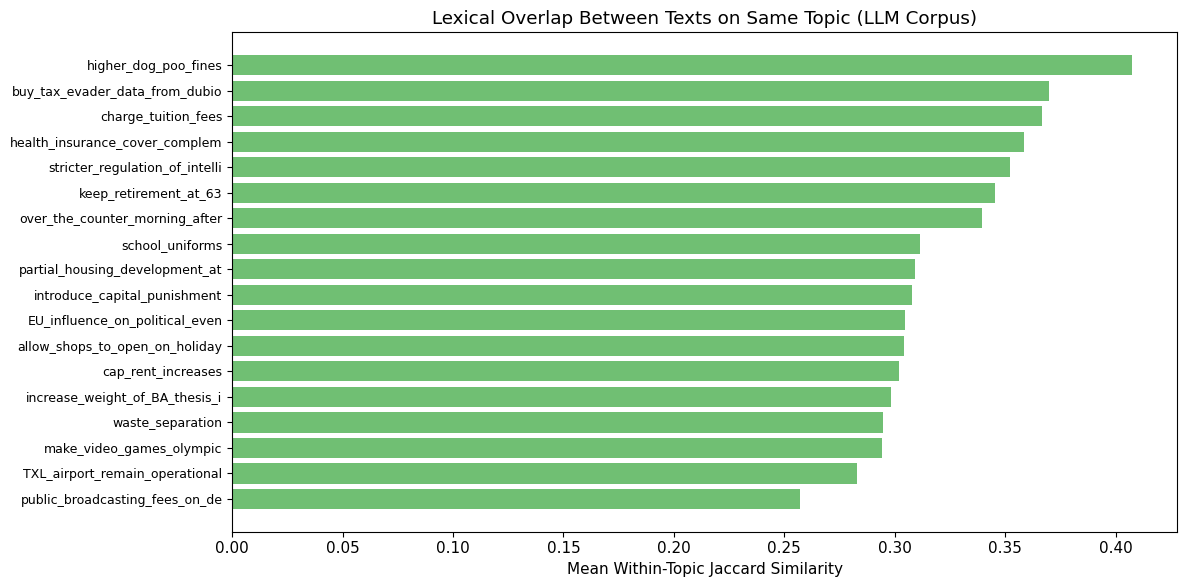

In [91]:
# plot top and bottom topics by jaccard
fig, ax = plt.subplots(figsize=(12, 6))
topics = [r[0][:30] for r in results]
means = [r[2] for r in results]
ax.barh(range(len(topics)), means, color='#4CAF50', alpha=0.8)
ax.set_yticks(range(len(topics)))
ax.set_yticklabels(topics, fontsize=9)
ax.set_xlabel('Mean Within-Topic Jaccard Similarity')
ax.set_title('Lexical Overlap Between Texts on Same Topic (LLM Corpus)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_topic_jaccard.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. summary table for report

In [92]:
# one big summary table
print("=" * 75)
print("SUMMARY TABLE")
print("=" * 75)
print(f"{'Metric':<35} {'Original':>12} {'Crowdsource':>12} {'LLM (Qwen)':>12}")
print("-" * 75)

summary = [
    ('Texts', len(orig), len(crowd), len(qwen)),
    ('Total ADUs', 
     sum(len(x['arggraph']['adu']) for x in orig),
     sum(len(x['arggraph']['adu']) for x in crowd),
     sum(len(x['arggraph']['adu']) for x in qwen)),
    ('Mean ADUs/text',
     f"{np.mean([len(x['arggraph']['adu']) for x in orig]):.1f}",
     f"{np.mean([len(x['arggraph']['adu']) for x in crowd]):.1f}",
     f"{np.mean([len(x['arggraph']['adu']) for x in qwen]):.1f}"),
    ('Pro ADUs %',
     f"{sum(1 for x in orig for a in x['arggraph']['adu'] if a['@type']=='pro')/sum(len(x['arggraph']['adu']) for x in orig)*100:.1f}",
     f"{sum(1 for x in crowd for a in x['arggraph']['adu'] if a['@type']=='pro')/sum(len(x['arggraph']['adu']) for x in crowd)*100:.1f}",
     f"{sum(1 for x in qwen for a in x['arggraph']['adu'] if a['@type']=='pro')/sum(len(x['arggraph']['adu']) for x in qwen)*100:.1f}"),
    ('Opp ADUs %',
     f"{sum(1 for x in orig for a in x['arggraph']['adu'] if a['@type']=='opp')/sum(len(x['arggraph']['adu']) for x in orig)*100:.1f}",
     f"{sum(1 for x in crowd for a in x['arggraph']['adu'] if a['@type']=='opp')/sum(len(x['arggraph']['adu']) for x in crowd)*100:.1f}",
     f"{sum(1 for x in qwen for a in x['arggraph']['adu'] if a['@type']=='opp')/sum(len(x['arggraph']['adu']) for x in qwen)*100:.1f}"),
    ('EDU≠ADU (restatement) %',
     f"{sum(1 for x in orig if len(x['arggraph']['edu'])!=len(x['arggraph']['adu']))/len(orig)*100:.1f}",
     f"{sum(1 for x in crowd if len(x['arggraph']['edu'])!=len(x['arggraph']['adu']))/len(crowd)*100:.1f}",
     f"{sum(1 for x in qwen if len(x['arggraph']['edu'])!=len(x['arggraph']['adu']))/len(qwen)*100:.1f}"),
    ('Claim at position 1/5',
     f"{sum(1 for x in orig if claim_position_fifth(x)==1)/len(orig)*100:.0f}%",
     f"{sum(1 for x in crowd if claim_position_fifth(x)==1)/len(crowd)*100:.0f}%",
     f"{sum(1 for x in qwen if claim_position_fifth(x)==1)/len(qwen)*100:.0f}%"),
    ('Mean tree depth',
     f"{np.mean(dep_o):.2f}",
     f"{np.mean(dep_c):.2f}",
     f"{np.mean(dep_q):.2f}"),
    ('Mean direct-to-root',
     f"{np.mean(br_o):.2f}",
     f"{np.mean(br_c):.2f}",
     f"{np.mean(br_q):.2f}"),
    ('Adjacent attachment %',
     f"{sum(1 for d in d_orig if abs(d)==1)/len(d_orig)*100:.1f}",
     f"{sum(1 for d in d_crowd if abs(d)==1)/len(d_crowd)*100:.1f}",
     f"{sum(1 for d in d_qwen if abs(d)==1)/len(d_qwen)*100:.1f}"),
    ('Corpus TTR', f"{l_o['corpus_ttr']:.3f}", f"{l_c['corpus_ttr']:.3f}", f"{l_q['corpus_ttr']:.3f}"),
    ('Vocabulary size', l_o['vocab'], l_c['vocab'], l_q['vocab']),
    ('Mean within-topic Jaccard', f"{l_o['mean_jacc']:.3f}", f"{l_c['mean_jacc']:.3f}", f"{l_q['mean_jacc']:.3f}"),
]

for row in summary:
    label = row[0]
    v1, v2, v3 = row[1], row[2], row[3]
    print(f"{label:<35} {str(v1):>12} {str(v2):>12} {str(v3):>12}")

SUMMARY TABLE
Metric                                  Original  Crowdsource   LLM (Qwen)
---------------------------------------------------------------------------
Texts                                        112          171          138
Total ADUs                                   576          932          925
Mean ADUs/text                               5.1          5.5          6.7
Pro ADUs %                                  78.3         86.4         81.1
Opp ADUs %                                  21.7         13.6         18.9
EDU≠ADU (restatement) %                      0.0         15.8         47.8
Claim at position 1/5                        43%          61%          99%
Mean tree depth                             1.68         1.87         2.01
Mean direct-to-root                         2.54         2.42         4.33
Adjacent attachment %                       56.2         42.8         41.8
Corpus TTR                                 0.254        0.169        0.144
Vocabulary